# 2D Structure Function / CROCO Data

This example will guide you through each step necessary to compute scalar-based structure functions from a 2D CROCO data.

$\textbf{General procedure}:$


1 -  Load a croco dataset, the dataset can be accessed https://doi.org/10.1175/JPO-D-18-0029.1

2 -  Format dataset to match pyturbo_sf inputs

3 -  Calculate Isotropic advective-SF $\delta u.\delta ADV$

4 -  Plot Isotropic advective-SF $\delta u.\delta ADV$ with isotropy and homogeneity errors

5 -  Calculate Bessel Energy Flux $\Pi_{u}$

6 -  Plot Bessel Energy Flux $\Pi_{u}$ with isotropy and homogeneity errors

$\textbf{Note:}$ Pick A bootsize which divides the data size by power of 2

$\textbf{Motivation:}$ This example provides an ideal comparison to the surface drifter structure function analysis presented in Pearson et al. (2019), who demonstrated significant biases between Lagrangian and Eulerian structure functions in the Gulf of Mexico. While their study relied on computationally expensive Lagrangian drifter deployments and the CROCO model data offers a cost-effective alternative for computing both traditional and advective structure functions. The advective structure functions implemented here follow the methodology that proved particularly valuable for diagnosing energy transfer in convergent regions where traditional structure functions become biased. This computational approach enables systematic exploration of submesoscale dynamics without the prohibitive costs of extensive field campaigns, while still capturing the essential physics of turbulent cascades in regions of strong surface convergence and divergence.

$\textbf{Reference:}$

Pearson, J., Fox-Kemper, B., Barkan, R., Choi, J., Bracco, A., & McWilliams, J. C. (2019). Impacts of convergence on structure functions from surface drifters in the Gulf of Mexico. Journal of Physical Oceanography, 49(3), 675-690. https://doi.org/10.1175/JPO-D-18-0029.1


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc
np.random.seed(42)

# Load the CROCO Dataset

In [2]:
path_data = '/home/aayouche/Downloads/'
idt = 10
dsh = xr.open_dataset(path_data+'/'+'surface.nc')
dsg = xr.open_dataset(path_data+'/'+'GOM_150_grd.nc')

lon = dsg.lon_rho
lat = dsg.lat_rho

lon_center = np.nanmin(lon)
utm_zone = int(1 + (lon_center + 180.0) / 6.0)

# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

x, y = proj(lon.values, lat.values) 

X = 0.25*(x[1:,1:] + x[1:,:-1] + x[:-1,:-1] + x[:-1,1:])
Y = 0.25*(y[1:,1:] + y[1:,:-1] + y[:-1,:-1] + y[:-1,1:])


u = np.array(dsh.u.isel(s_rho=0,time=idt))
u = 0.5*(u[1:,:] + u[:-1,:])
v = np.array(dsh.v.isel(s_rho=0,time=idt))
v = 0.5*(v[:,1:] + v[:,:-1])

dudx = np.gradient(u,axis=1)/(2*150.)
dvdx = np.gradient(v,axis=1)/(2*150.)
dudy = np.gradient(u,axis=0)/(2*150.)
dvdy = np.gradient(v,axis=0)/(2*150.)

adv_u = u*dudx + v*dudy

adv_v = u*dvdx + v*dvdy

temp = np.array(dsh.temp.isel(s_rho=0,time=idt))

temp = 0.25*(temp[1:,1:] + temp[1:,:-1] + temp[:-1,:-1] + temp[:-1,1:])
f = 1.0e-4
vort = dvdx - dudy + f
dvortdx = np.gradient(vort,axis=1)/(2*150.)
dvortdy = np.gradient(vort,axis=0)/(2*150.)

adv_vort = u*dvortdx + v*dvortdy

gc.collect()

70

# Make A quick Plot

Text(0, 0.5, 'Y [km]')

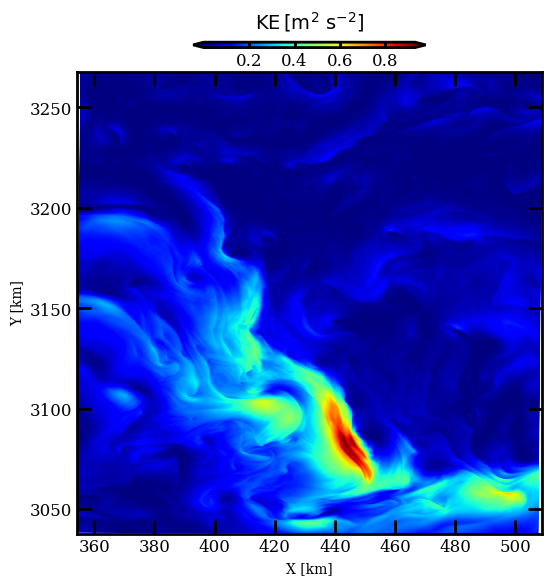

In [3]:
fig,ax = plt.subplots(figsize=(6,6))
im = ax.pcolormesh(X/1.0e3,Y/1.0e3,0.5*(u**2 + v**2),cmap='jet',shading='gouraud')

pos1cb = ax.get_position()
cbar_ax = fig.add_axes([pos1cb.x0+pos1cb.width/4., pos1cb.y0+0.04+pos1cb.height , pos1cb.width/2. , 0.009])
cbar = fig.colorbar(im, cax=cbar_ax,orientation='horizontal',\
                            extend='both',ticks=np.arange(0,1,0.2))
cbar.set_label(r'$ {\rm KE \,  [} {\rm m^{2}~} {\rm s^{-2}]}$',fontsize= fontsize + 2 ,labelpad=10)
cbar.ax.tick_params(labelsize=fontsize,direction='in',width=linewidth,size=4)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('both')
cbar.outline.set_linewidth( linewidth )
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth( linewidth )
    ax.spines[axis].set_color('k')
ax.tick_params(direction='in',bottom='on',top='on',left='on',right='on')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

In [4]:
gc.collect()

3323

# Format Dataset

In [5]:
# Create the xarray dataset
ds = xr.Dataset({
    'u': (['y', 'x'], u),
    'v': (['y', 'x'], v),
    'adv_u':(['y', 'x'], adv_u),
    'adv_v':(['y', 'x'], adv_v),
    'temperature':(['y', 'x'], temp),
    'vort':(['y', 'x'], vort),
    'adv_vort':(['y', 'x'], adv_vort),


}, coords={
    'x': (['y', 'x'], X),
    'y': (['y', 'x'], Y)
})



In [6]:
ds

<xarray.Dataset> Size: 69MB
Dimensions:      (y: 1537, x: 1025)
Coordinates:
    y            (y, x) float64 13MB 3.039e+06 3.039e+06 ... 3.267e+06 3.267e+06
    x            (y, x) float64 13MB 3.542e+05 3.544e+05 ... 5.086e+05 5.088e+05
Data variables:
    u            (y, x) float32 6MB -0.3907 -0.4025 -0.4012 ... 0.01855 0.01787
    v            (y, x) float32 6MB 0.08256 0.09225 0.1009 ... 0.0189 0.01809
    adv_u        (y, x) float32 6MB 1.877e-05 1.042e-05 ... 2.56e-07 9.305e-08
    adv_v        (y, x) float32 6MB -1.566e-05 -1.693e-05 ... -3.382e-07
    temperature  (y, x) float32 6MB 25.06 25.06 25.06 ... 20.97 20.97 20.97
    vort         (y, x) float32 6MB 9.174e-05 9.375e-05 ... 7.981e-05 8.993e-05
    adv_vort     (y, x) float32 6MB -6.696e-09 -4.602e-09 ... 7.135e-10

# Keywords for Bessel and Isotropic SF

In [7]:
# Isotropic

sf_kwargs_is = dict(
    ds=ds,
    bins={
        'r': np.logspace(np.log10(1.0e3), np.log10(150.0e3), 12)
    },
    bootsize={'y': 24, 'x': 16},
    initial_nbootstrap=5000,
    max_nbootstrap=5000,
    step_nbootstrap=0,
    confidence_interval=0.95,
    n_jobs=-1,
    backend='loky',
    seed=42
)

# Bessel

sf_kwargs_bs = dict(
    ds=ds,
    wavenumbers={
        'k': 2*np.pi/np.logspace(np.log10(1.0e3), np.log10(150.0e3), 12)
    },
    bootsize={'y': 24, 'x': 16},
    initial_nbootstrap=5000,
    max_nbootstrap=5000,
    step_nbootstrap=0,
    confidence_interval=0.95,
    n_jobs=-1,
    backend='loky',
    seed=42
)

# Calculate Isotropic advective-SF $\delta u.\delta ADV$

In [8]:
%%time
iso_sf_adv = psf.get_isotropic_sf_2d(**sf_kwargs_is,
    order=1,
    variables_names=["u","v","adv_u","adv_v"],
    fun='advective',
    convergence_eps=1.0e-8,
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 24, 'x': 16}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16, 32, 64]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: advective
Variables: ['u', 'v', 'adv_u', 'adv_v'], Order: 1
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 714 bootstraps
Processing spacing 2 with 714 bootstraps
Processing spacing 4 with 714 bootstraps
Processing spacing 8 with 714 bootstraps
Processing spacing 16 with 714 bootstraps
Processing spacing 32 with 714 bootstraps
Processing spacing 64 with 714 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 201999168
Bins with points: 11/11
Marked 3 bins as converged (converged_eps)
Marked 8 bins as converged (max_bootstraps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data (>10 points): 11
  Converged bins: 11
  

# Plot Isotropic advective-SF $\delta u.\delta ADV$

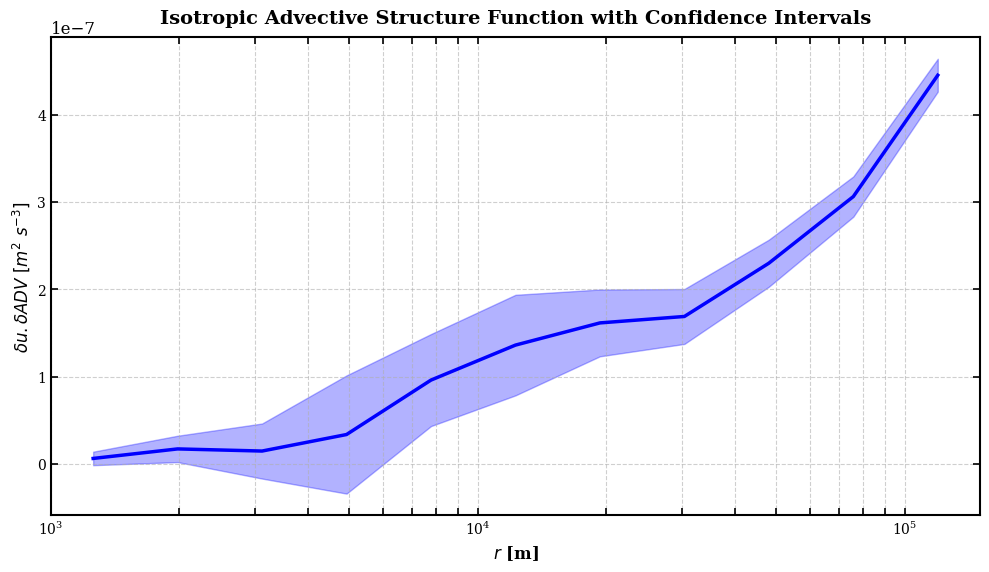

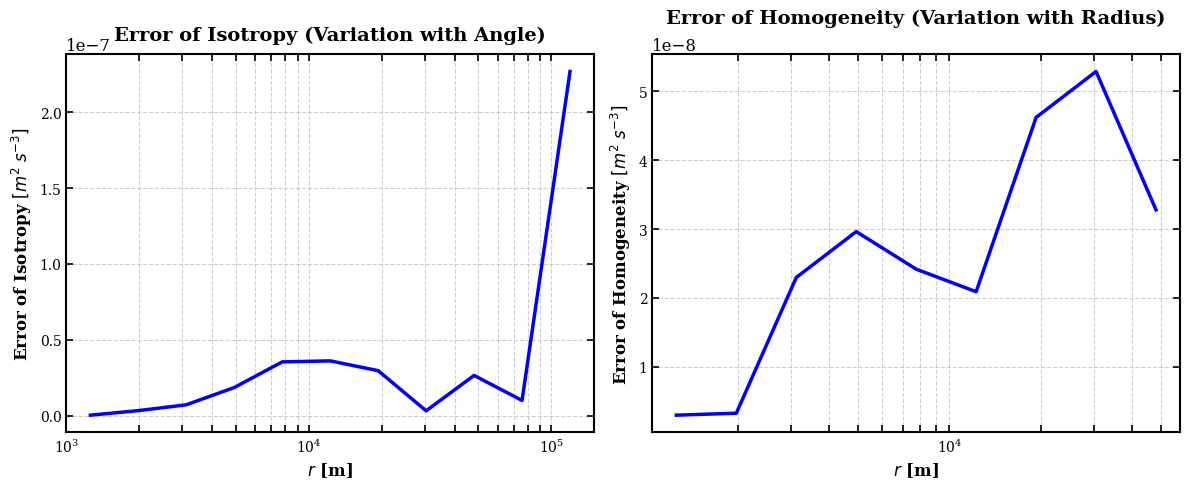

CPU times: user 357 ms, sys: 8.35 ms, total: 365 ms
Wall time: 362 ms


In [9]:
%%time

# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_adv.r, iso_sf_adv.sf, 'b-', linewidth=2.5)

plt.fill_between(iso_sf_adv.r, 
                iso_sf_adv.ci_lower, 
                iso_sf_adv.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta u.\delta ADV~[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Advective Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_adv.r, iso_sf_adv.error_isotropy, 'b-', linewidth=2.5)

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_adv.r_subset, iso_sf_adv.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

In [10]:
gc.collect()

10520

# Calculate Bessel $\Pi_{u}$

In [11]:
%%time

iso_sf_bessel = psf.get_energy_flux_2d(**sf_kwargs_bs,
    variables_names=["u","v","adv_u","adv_v"],
    order=1,
    fun='advective',
    convergence_eps=1.0e-8
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 24, 'x': 16}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16, 32, 64]

STARTING ENERGY FLUX COMPUTATION
Function type: advective
Variables: ['u', 'v', 'adv_u', 'adv_v'], Order: 1
Confidence level: 0.95
Formula: Π(K) = -K/2 ∫ SF̃(r) J₁(Kr) dr


INITIAL BOOTSTRAP PHASE (Energy Flux)
Processing spacing 1 with 714 bootstraps
Processing spacing 2 with 714 bootstraps
Processing spacing 4 with 714 bootstraps
Processing spacing 8 with 714 bootstraps
Processing spacing 16 with 714 bootstraps
Processing spacing 32 with 714 bootstraps
Processing spacing 64 with 714 bootstraps

CALCULATING WAVENUMBER DENSITIES
Total points collected: 22970808
Wavenumbers with flux estimates: 12/12
Marked 10 wavenumbers as converged (converged_eps)
Marked 2 wavenumbers as converged (max_bootstraps)

STARTING ADAPTIVE CONVERGENCE LOOP
All wavenumbers have converged or reached max boo

# Plot Bessel $\Pi_{u}$

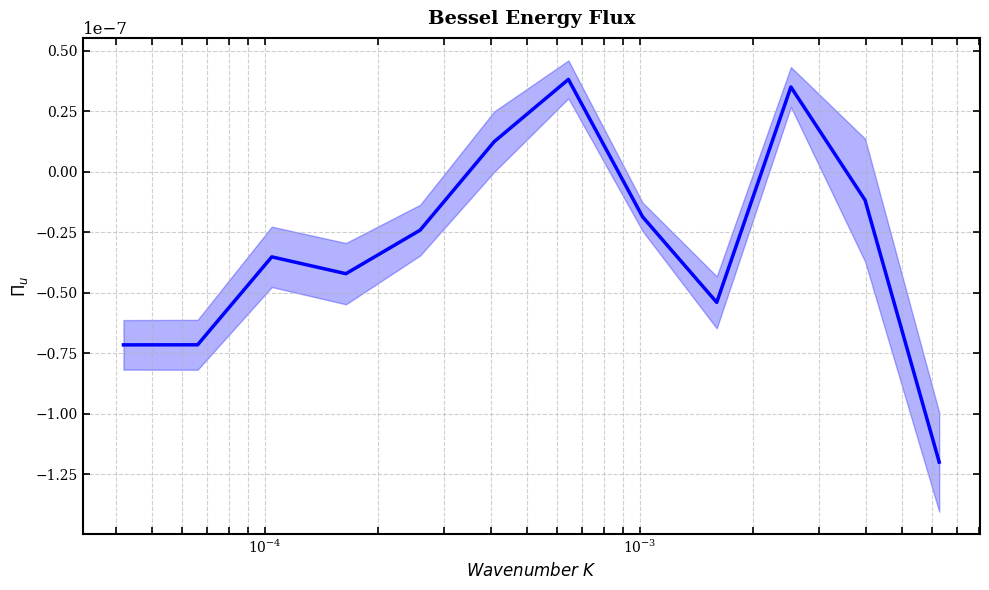

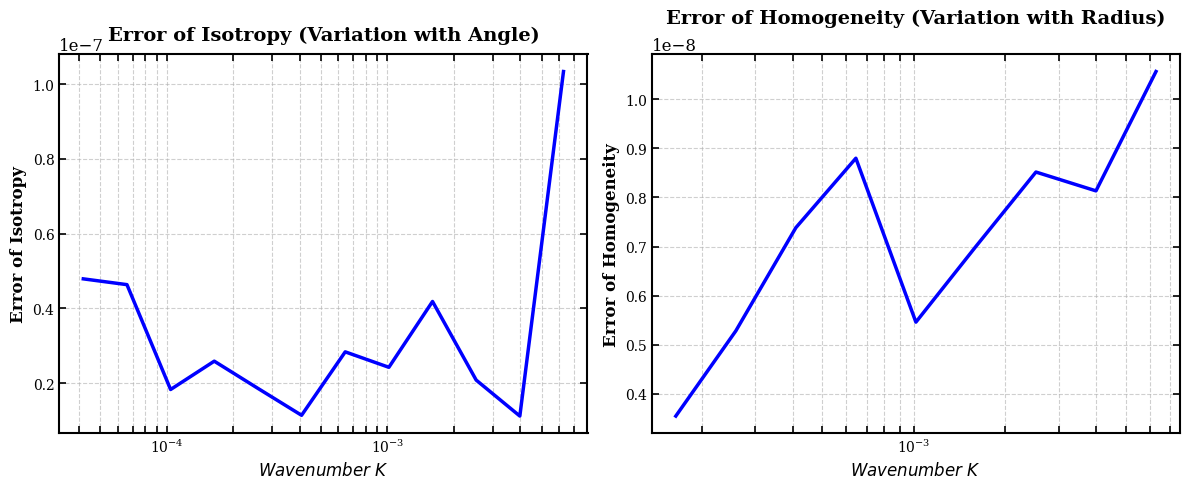

In [12]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_bessel.k, iso_sf_bessel.energy_flux, 'b-', linewidth=2.5)

plt.fill_between(iso_sf_bessel.k, 
                iso_sf_bessel.ci_lower, 
                iso_sf_bessel.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$Wavenumber~K$', fontsize=12, fontweight='bold')
plt.ylabel(r'$\Pi_{u}$', fontsize=12, fontweight='bold')
plt.title('Bessel Energy Flux', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_bessel.k, iso_sf_bessel.error_isotropy, 'b-', linewidth=2.5)

plt.xlabel(r'$Wavenumber~K$', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_bessel.k_subset, iso_sf_bessel.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$Wavenumber~K$', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

## Physical Interpretation: Spectral Energy Flux via Bessel Transform

The Bessel transform method converts structure functions to spectral energy flux, bridging real-space and Fourier-space analyses:

- **Spectral flux $\Pi(k)$:** Represents the rate of energy transfer across wavenumber $k$. Negative values indicate inverse cascade (energy to larger scales/smaller $k$).
- **Inertial range:** A plateau in $\Pi(k)$ confirms constant flux, the hallmark of a turbulent cascade.
- **Advantages over FFT:** The Bessel approach handles irregular domains, missing data, and provides uncertainty quantification through bootstrap.
- **Comparison with spectral methods:** Agreement with traditional spectral flux estimates validates both approaches; disagreement may indicate anisotropy or non-stationarity.

This technique is especially valuable for satellite data where regular grids and periodic boundaries are not available.